# Kalman Filter — Estimating the Hidden Truth from Noisy Clues

> *"A Kalman filter is just a fancy way of taking a guess you already have, looking at a noisy measurement, and deciding **how much to trust each one**."*

The Kalman Filter is one of the most beautiful algorithms in applied math. It powers GPS, spacecraft navigation, self-driving cars — and in **quant trading** it's used to estimate things you *cannot observe directly*: a time-varying hedge ratio, a "fair value" hiding under microstructure noise, or a slowly drifting mean.

This notebook builds it from **first principles**:

1. The big idea — why two blurry guesses make one sharp guess
2. The 1D heart of it — multiplying two Gaussians
3. The state-space model
4. The full predict/update equations (derived, not dropped)
5. A from-scratch numpy implementation
6. Tracking a moving object
7. The tug-of-war between process noise $Q$ and measurement noise $R$
8. A quant application

> **📌 Quant interview flag:** Kalman filters come up constantly for *"how would you estimate a signal that changes over time?"* and *"how do you trade off responsiveness vs smoothness?"* Knowing the predict/update intuition cold is a real edge.

---

## 1 · The Big Idea — two blurry guesses make one sharp guess

Imagine you're tracking a stock's hidden "true" price. You have **two sources of information**:

1. **A prediction** — "based on where it was and how it was moving, it *should* be near \$100." This has some uncertainty.
2. **A measurement** — your data feed says \$101, but the feed is noisy (bid-ask bounce, stale quotes). This *also* has uncertainty.

Neither is perfect. The genius of Kalman is the answer to:

> **How do I optimally combine a noisy prediction with a noisy measurement?**

The answer: treat both as **Gaussians (bell curves)** — each centered at its best guess, with a width equal to its uncertainty. Then *multiply them*. The product is a **narrower** Gaussian that sits between the two, **pulled toward whichever was more confident** (narrower).

> **Key insight:** Combining two independent noisy estimates always gives you something *more certain than either one alone*. Information adds up. This single idea — repeated every time step — *is* the Kalman filter.

Let's see it.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

# Our consistent color palette
C = {
    "predict": "steelblue",
    "measure": "tomato",
    "fused":   "mediumseagreen",
    "truth":   "navy",
    "accent":  "darkorange",
}

np.random.seed(7)
print("Setup ready.")

Setup ready.


## 2 · Fusing Two Gaussians — the 1D heart of it

A 1D Gaussian is described by just two numbers: its **mean** $\mu$ (the best guess) and its **variance** $\sigma^2$ (how unsure we are — bigger = blurrier).

$$
\mathcal{N}(x \mid \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\,\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

When you have two **independent** Gaussian estimates of the same quantity and multiply them, magic happens — the result is *another* Gaussian with:

$$
\boxed{\;\mu = \frac{\sigma_2^2\,\mu_1 + \sigma_1^2\,\mu_2}{\sigma_1^2 + \sigma_2^2}, \qquad
\sigma^2 = \frac{\sigma_1^2\,\sigma_2^2}{\sigma_1^2 + \sigma_2^2}\;}
$$

These look messy, so let's rewrite them in the form the Kalman filter actually uses. Define the **gain**

$$
K = \frac{\sigma_1^2}{\sigma_1^2 + \sigma_2^2}
$$

Then the formulas become the clean, intuitive pair:

$$
\mu = \mu_1 + K\,(\mu_2 - \mu_1), \qquad \sigma^2 = (1 - K)\,\sigma_1^2
$$

Let's decode every piece:

| Symbol | Meaning | Intuition |
|--------|---------|-----------|
| $\mu_1, \sigma_1^2$ | the **prediction** | what we believed *before* the new clue |
| $\mu_2, \sigma_2^2$ | the **measurement** | the noisy new clue |
| $\mu_2 - \mu_1$ | the **innovation** | "how surprised am I?" — the gap between clue and belief |
| $K$ | the **gain** (0→1) | "how much do I trust the new clue?" |
| $\mu_1 + K\,(\mu_2-\mu_1)$ | updated mean | start at old belief, **nudge** toward the surprise |
| $(1-K)\sigma_1^2$ | updated variance | always **shrinks** — we got more certain |

> **Key insight:** $K$ is a trust dial. If the measurement is super precise ($\sigma_2^2 \to 0$), then $K \to 1$ and we jump fully to it. If the measurement is garbage ($\sigma_2^2 \to \infty$), then $K \to 0$ and we ignore it. The Kalman filter is *nothing but* computing this trust dial, automatically, every step.

---

In [2]:
def gaussian(x, mu, var):
    return np.exp(-0.5 * (x - mu)**2 / var) / np.sqrt(2 * np.pi * var)

def fuse(mu1, var1, mu2, var2):
    '''Multiply two Gaussians -> a new (narrower) Gaussian.'''
    K   = var1 / (var1 + var2)          # the gain / trust dial
    mu  = mu1 + K * (mu2 - mu1)         # nudge old belief toward the surprise
    var = (1 - K) * var1               # uncertainty always shrinks
    return mu, var, K

# Prediction: "should be near 100", fairly unsure
mu1, var1 = 100.0, 4.0
# Measurement: feed says 103, a bit more precise
mu2, var2 = 103.0, 2.0

mu_f, var_f, K = fuse(mu1, var1, mu2, var2)
print(f"Prediction : mu={mu1:.2f}, sigma={np.sqrt(var1):.2f}")
print(f"Measurement: mu={mu2:.2f}, sigma={np.sqrt(var2):.2f}")
print(f"Gain K     : {K:.3f}  (we trust the measurement {K*100:.0f}% of the way)")
print(f"FUSED      : mu={mu_f:.2f}, sigma={np.sqrt(var_f):.2f}  <- narrowest of the three")

Prediction : mu=100.00, sigma=2.00
Measurement: mu=103.00, sigma=1.41
Gain K     : 0.667  (we trust the measurement 67% of the way)
FUSED      : mu=102.00, sigma=1.15  <- narrowest of the three


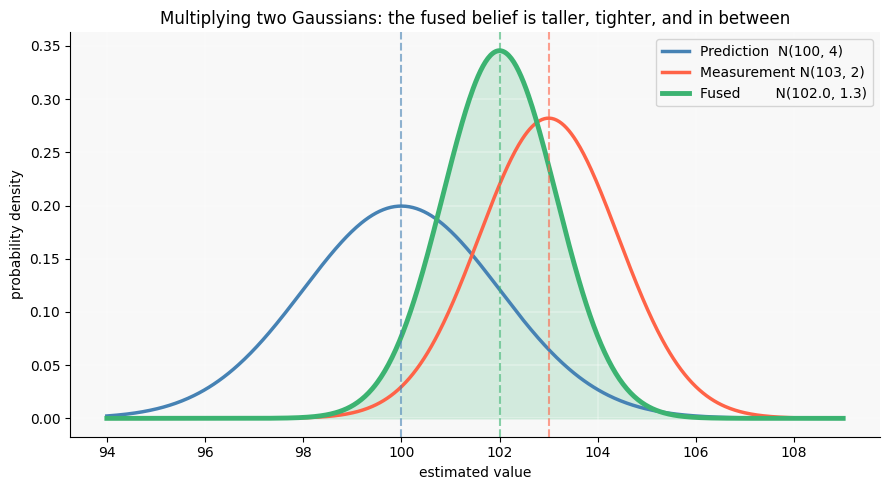

In [3]:
x = np.linspace(94, 109, 600)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, gaussian(x, mu1, var1), color=C["predict"], lw=2.5, label=f"Prediction  N({mu1:.0f}, {var1:.0f})")
ax.plot(x, gaussian(x, mu2, var2), color=C["measure"], lw=2.5, label=f"Measurement N({mu2:.0f}, {var2:.0f})")
ax.plot(x, gaussian(x, mu_f, var_f), color=C["fused"], lw=3.5, label=f"Fused        N({mu_f:.1f}, {var_f:.1f})")
ax.fill_between(x, gaussian(x, mu_f, var_f), color=C["fused"], alpha=0.20)

for m, c in [(mu1, C["predict"]), (mu2, C["measure"]), (mu_f, C["fused"])]:
    ax.axvline(m, color=c, ls="--", alpha=0.6)

ax.set_xlabel("estimated value")
ax.set_ylabel("probability density")
ax.set_title("Multiplying two Gaussians: the fused belief is taller, tighter, and in between")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Notice three things in that plot:

- The green (fused) curve is **taller and skinnier** than either input — we're *more* confident than before.
- Its peak sits **between** the two inputs, but **closer to the measurement** because the measurement was more precise ($\sigma_2 < \sigma_1$).
- We never "threw away" either estimate; we *weighted* them.

That's one Kalman update. Now we just need to (a) generalize from a single number to a full **state vector** (position *and* velocity), and (b) add a **prediction step** that moves our belief forward in time between measurements.

---

## 3 · The State-Space Model — describing a system that moves

Before filtering, we need a model of **what we're tracking**. The Kalman filter assumes the world works like this:

**The state evolves (the "physics"):**
$$
\mathbf{x}_t = F\,\mathbf{x}_{t-1} + \mathbf{w}_t, \qquad \mathbf{w}_t \sim \mathcal{N}(\mathbf{0}, Q)
$$

**We observe a noisy slice of it:**
$$
\mathbf{z}_t = H\,\mathbf{x}_t + \mathbf{v}_t, \qquad \mathbf{v}_t \sim \mathcal{N}(\mathbf{0}, R)
$$

Let's make this concrete with a **constant-velocity tracker**. The hidden state is position *and* velocity:

$$
\mathbf{x} = \begin{bmatrix} p \\ v \end{bmatrix}
\quad\text{(position, velocity)}
$$

**The transition matrix $F$** encodes the physics "new position = old position + velocity × dt; velocity stays the same":

$$
F = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}
\;\Rightarrow\;
\begin{bmatrix} p_t \\ v_t \end{bmatrix}
= \begin{bmatrix} p_{t-1} + v_{t-1}\,\Delta t \\ v_{t-1} \end{bmatrix}
$$

**The observation matrix $H$** says "our sensor only sees position, not velocity":

$$
H = \begin{bmatrix} 1 & 0 \end{bmatrix}
\;\Rightarrow\;
z_t = p_t + \text{noise}
$$

| Symbol | Shape | Role | Analogy |
|--------|-------|------|---------|
| $\mathbf{x}$ | $n\times 1$ | hidden **state** we want | the truth we're chasing |
| $F$ | $n\times n$ | **transition** — how state evolves | the "physics engine" |
| $Q$ | $n\times n$ | **process noise** covariance | how much the physics *lies* / how jumpy reality is |
| $\mathbf{z}$ | $m\times 1$ | **measurement** | the noisy clue we actually see |
| $H$ | $m\times n$ | **observation** — state → measurement | the "sensor" |
| $R$ | $m\times m$ | **measurement noise** covariance | how much the sensor *lies* |
| $P$ | $n\times n$ | state **covariance** | our current uncertainty (a fuzzy cloud) |

> **Key insight:** $Q$ and $R$ are the two knobs that matter. **$Q$ large** = "reality surprises me, don't over-trust my predictions." **$R$ large** = "my sensor is noisy, don't over-trust measurements." Their *ratio* sets how twitchy vs. smooth the filter is. **This trade-off is a classic quant interview question.**

---

## 4 · The Kalman Filter Equations — predict, then update

Every time step does two phases. Phase 1 is the **prediction step** (the prediction Gaussian from Section 1). Phase 2 is the **update step** (fusing in the measurement).

### Phase 1 — Predict (move belief forward in time)

$$
\hat{\mathbf{x}}_t^- = F\,\hat{\mathbf{x}}_{t-1} \qquad\text{(push the mean through the physics)}
$$
$$
P_t^- = F\,P_{t-1}\,F^\top + Q \qquad\text{(uncertainty grows; we coasted blind, and added process noise }Q\text{)}
$$

The minus superscript means *"before seeing the measurement."* Intuition: between measurements we **lose confidence** — that's why $P$ grows. Adding $Q$ is admitting "the world might have done something my model didn't capture."

### Phase 2 — Update (fold in the measurement)

$$
\mathbf{y}_t = \mathbf{z}_t - H\,\hat{\mathbf{x}}_t^- \qquad\text{(the \textbf{innovation}: how surprised are we?)}
$$
$$
S_t = H\,P_t^-\,H^\top + R \qquad\text{(uncertainty of that surprise: our doubt + sensor doubt)}
$$
$$
K_t = P_t^-\,H^\top\,S_t^{-1} \qquad\text{(the \textbf{Kalman gain}: the trust dial, now a matrix)}
$$
$$
\hat{\mathbf{x}}_t = \hat{\mathbf{x}}_t^- + K_t\,\mathbf{y}_t \qquad\text{(nudge the prediction toward the surprise)}
$$
$$
P_t = (I - K_t H)\,P_t^- \qquad\text{(shrink uncertainty — we just learned something)}
$$

Compare the update to our 1D fusion from Section 2 — it's **literally the same formula**, just with matrices:

$$
\underbrace{\hat{\mathbf{x}} = \hat{\mathbf{x}}^- + K(\mathbf{z} - H\hat{\mathbf{x}}^-)}_{\text{Kalman}}
\qquad\longleftrightarrow\qquad
\underbrace{\mu = \mu_1 + K(\mu_2 - \mu_1)}_{\text{1D fusion}}
$$

> **Why does $K = P^- H^\top S^{-1}$?** It's the matrix version of $K=\frac{\sigma_1^2}{\sigma_1^2+\sigma_2^2}$. The numerator $P^-H^\top$ is "how much our state uncertainty shows up in measurement space"; dividing by $S$ (total surprise uncertainty) normalizes it to a fraction between 0 and 1. **Big sensor noise $R$ → big $S$ → small $K$ → ignore the measurement.** Exactly the trust dial from Section 1.

> **📌 Quant interview flag:** Be ready to recite *predict → innovation → gain → update* and explain in one sentence what each line does. Interviewers love "what happens to the gain if $R \to \infty$?" (Answer: $K\to 0$, the filter ignores data and just coasts on its model.)

---

In [4]:
class KalmanFilter:
    '''A minimal, from-scratch linear Kalman filter.'''

    def __init__(self, F, H, Q, R, x0, P0):
        self.F = np.asarray(F, float)   # state transition  (n x n)
        self.H = np.asarray(H, float)   # observation       (m x n)
        self.Q = np.asarray(Q, float)   # process noise cov (n x n)
        self.R = np.asarray(R, float)   # measurement noise (m x m)
        self.x = np.asarray(x0, float)  # state estimate    (n,)
        self.P = np.asarray(P0, float)  # state covariance  (n x n)
        self.n = self.F.shape[0]

    def predict(self):
        # Phase 1: push mean through physics; let uncertainty grow by Q
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x

    def update(self, z):
        # Phase 2: fuse in the measurement z
        z = np.atleast_1d(z)
        y = z - self.H @ self.x                       # innovation (surprise)
        S = self.H @ self.P @ self.H.T + self.R       # innovation covariance
        K = self.P @ self.H.T @ np.linalg.inv(S)      # Kalman gain (trust dial)
        self.x = self.x + K @ y                       # corrected estimate
        I = np.eye(self.n)
        self.P = (I - K @ self.H) @ self.P            # shrink uncertainty
        return self.x, K

print("KalmanFilter class defined: .predict() then .update(z) each step.")

KalmanFilter class defined: .predict() then .update(z) each step.


## 5 · Dataset — tracking a noisy moving object

Let's generate a ground-truth object that moves with (roughly) constant velocity, then **hide it** behind heavy measurement noise. The filter only ever sees the noisy red dots — never the true blue line. Its job: recover the truth.

This is exactly the quant setting: the **true price/signal** drifts smoothly, but every print you observe is corrupted by microstructure noise.

---

In [5]:
# --- Ground truth: constant-velocity motion with a tiny bit of wobble ---
dt   = 1.0
T    = 100
true_v = 0.6                       # true velocity (units per step)

true_p = np.zeros(T)
v = true_v
for t in range(1, T):
    v += np.random.normal(0, 0.03)          # velocity drifts slightly (real process noise)
    true_p[t] = true_p[t-1] + v * dt

# --- Measurements: position only, badly corrupted ---
meas_noise_std = 4.0
measurements = true_p + np.random.normal(0, meas_noise_std, size=T)

print(f"{T} steps. True final position = {true_p[-1]:.1f}")
print(f"Measurement noise std = {meas_noise_std}  (the red cloud the filter must see through)")

100 steps. True final position = 51.8
Measurement noise std = 4.0  (the red cloud the filter must see through)


In [6]:
# --- Configure the filter ---
F = np.array([[1, dt],
              [0,  1]])            # constant-velocity physics
H = np.array([[1, 0]])            # we only measure position

q = 0.05                          # process-noise scale (trust in physics)
Q = q * np.array([[dt**4/4, dt**3/2],
                  [dt**3/2, dt**2]])   # standard CV process-noise structure
R = np.array([[meas_noise_std**2]])    # we honestly tell it the sensor variance

x0 = np.array([measurements[0], 0.0])  # start at first measurement, zero velocity
P0 = np.eye(2) * 50.0                  # very unsure at first (big initial cloud)

kf = KalmanFilter(F, H, Q, R, x0, P0)

# --- Run the filter, recording everything ---
est_p, est_v, gain_hist, var_hist = [], [], [], []
for t in range(T):
    kf.predict()
    (x, K) = kf.update(measurements[t])
    est_p.append(x[0]);  est_v.append(x[1])
    gain_hist.append(K[0, 0]);  var_hist.append(kf.P[0, 0])

est_p   = np.array(est_p)
est_v   = np.array(est_v)
gain_hist = np.array(gain_hist)
var_hist  = np.array(var_hist)

rmse_meas = np.sqrt(np.mean((measurements - true_p)**2))
rmse_kf   = np.sqrt(np.mean((est_p - true_p)**2))
print(f"RMSE of raw measurements vs truth : {rmse_meas:.3f}")
print(f"RMSE of Kalman estimate vs truth  : {rmse_kf:.3f}")
print(f"--> Kalman reduced error by {100*(1-rmse_kf/rmse_meas):.0f}%")

RMSE of raw measurements vs truth : 3.852
RMSE of Kalman estimate vs truth  : 1.954
--> Kalman reduced error by 49%


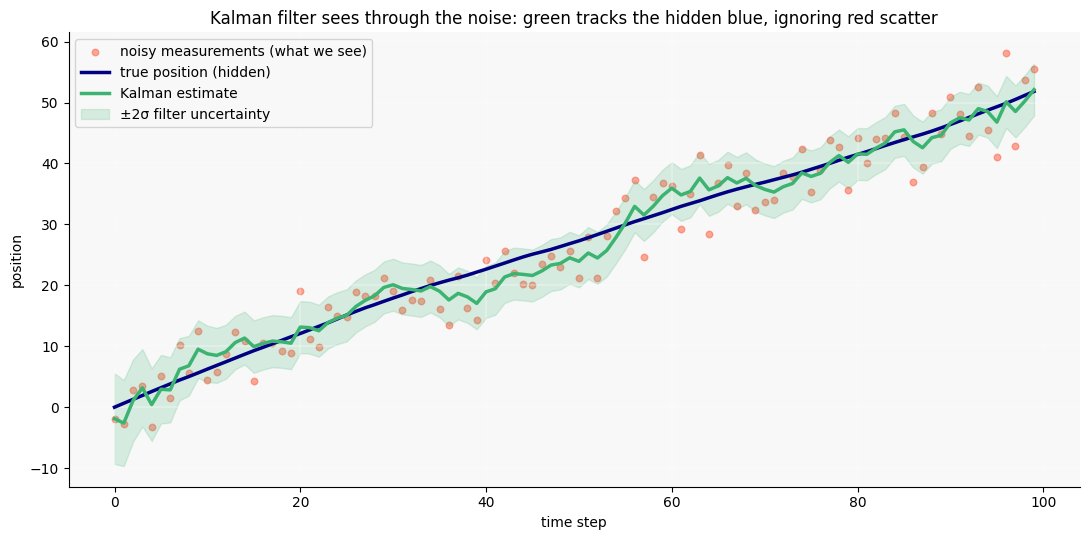

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.scatter(range(T), measurements, color=C["measure"], s=22, alpha=0.55, label="noisy measurements (what we see)")
ax.plot(true_p, color=C["truth"], lw=2.5, label="true position (hidden)")
ax.plot(est_p, color=C["fused"], lw=2.5, label="Kalman estimate")

# 95% confidence band from the filter's own variance
ax.fill_between(range(T), est_p - 2*np.sqrt(var_hist), est_p + 2*np.sqrt(var_hist),
                color=C["fused"], alpha=0.18, label="±2σ filter uncertainty")

ax.set_xlabel("time step")
ax.set_ylabel("position")
ax.set_title("Kalman filter sees through the noise: green tracks the hidden blue, ignoring red scatter")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The green estimate hugs the hidden blue truth, even though it **only ever saw the red dots**. And it gives you a free uncertainty band — something a simple moving average can't.

Now look *under the hood* at the two quantities that drive everything: the **Kalman gain** and the **estimate variance**.

---

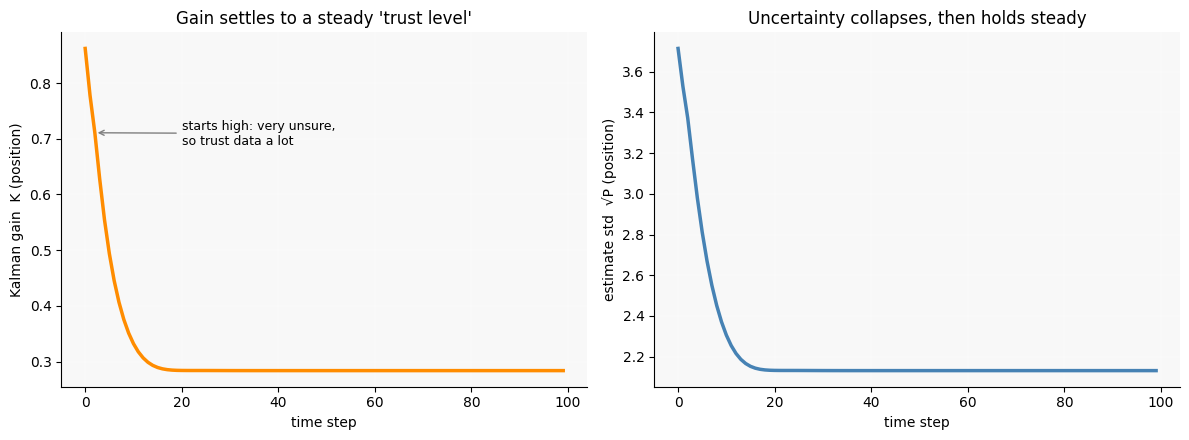

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(gain_hist, color=C["accent"], lw=2.5)
ax1.set_xlabel("time step")
ax1.set_ylabel("Kalman gain  K (position)")
ax1.set_title("Gain settles to a steady 'trust level'")
ax1.grid(alpha=0.3)
ax1.annotate("starts high: very unsure,\nso trust data a lot",
             xy=(2, gain_hist[2]), xytext=(20, 0.8*gain_hist.max()),
             arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9)

ax2.plot(np.sqrt(var_hist), color=C["predict"], lw=2.5)
ax2.set_xlabel("time step")
ax2.set_ylabel("estimate std  √P (position)")
ax2.set_title("Uncertainty collapses, then holds steady")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

> **Key insight:** Both curves **converge to a constant**. After a brief "warm-up," the filter reaches a *steady-state gain* — the optimal fixed trade-off between trusting its model and trusting the data, given $Q$ and $R$. (In fact you can solve for this steady state directly via the *Riccati equation* — a nice thing to name-drop in an interview.)

This is why people sometimes implement a Kalman filter as just a fixed-coefficient filter: once it converges, $K$ stops changing.

---

## 6 · The Tug-of-War: Process Noise $Q$ vs Measurement Noise $R$

This is the **most important practical knob** and a favorite interview topic. Only the **ratio** $Q/R$ matters:

- **$Q$ small / $R$ large** → "trust my model, distrust the data." Filter is **smooth & laggy** — it glides through noise but reacts slowly to real changes.
- **$Q$ large / $R$ small** → "distrust my model, trust the data." Filter is **twitchy & responsive** — it tracks turns instantly but lets noise through.

Sound familiar? It's the **exact same bias-variance / smoothing-vs-responsiveness trade-off** as choosing the window of a moving average — but principled.

Let's watch the same data filtered three ways.

---

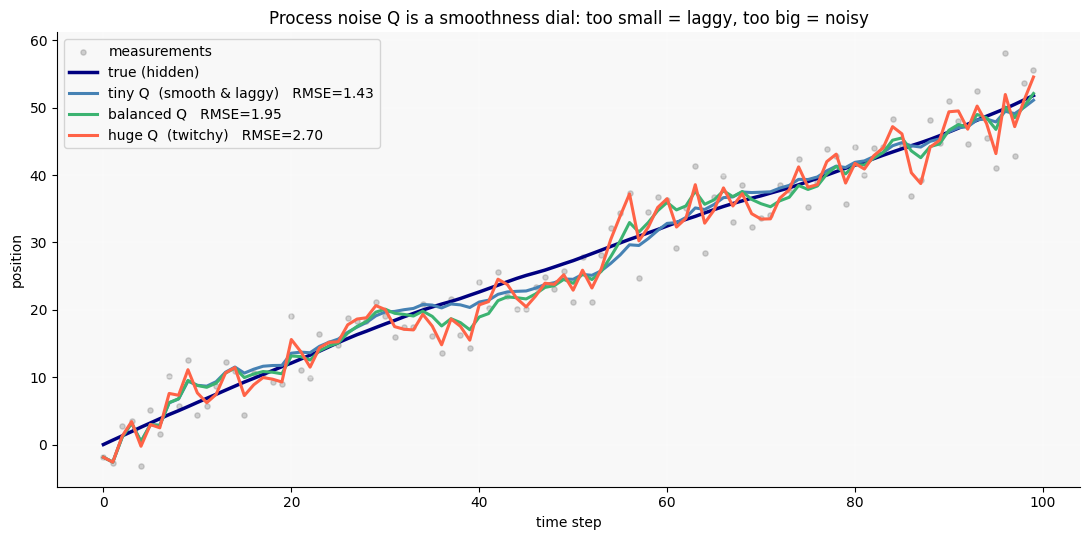

In [9]:
def run_filter(q_scale):
    Qx = q_scale * np.array([[dt**4/4, dt**3/2],
                             [dt**3/2, dt**2]])
    kf = KalmanFilter(F, H, Qx, R, np.array([measurements[0], 0.0]), np.eye(2)*50)
    out = []
    for t in range(T):
        kf.predict()
        x, _ = kf.update(measurements[t])
        out.append(x[0])
    return np.array(out)

settings = [(0.001, "tiny Q  (smooth & laggy)", C["predict"]),
            (0.05,  "balanced Q",                C["fused"]),
            (5.0,   "huge Q  (twitchy)",         C["measure"])]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.scatter(range(T), measurements, color="gray", s=14, alpha=0.35, label="measurements")
ax.plot(true_p, color=C["truth"], lw=2.5, label="true (hidden)")
for q_scale, name, col in settings:
    est = run_filter(q_scale)
    r = np.sqrt(np.mean((est - true_p)**2))
    ax.plot(est, color=col, lw=2.2, label=f"{name}   RMSE={r:.2f}")

ax.set_xlabel("time step")
ax.set_ylabel("position")
ax.set_title("Process noise Q is a smoothness dial: too small = laggy, too big = noisy")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

See it clearly: the blue (tiny $Q$) line is glassy-smooth but **lags** the truth; the red (huge $Q$) line is jumpy and lets noise through; the green (balanced $Q$) wins. Tuning $Q/R$ *is* the art of applying a Kalman filter.

### Interactive: feel the trade-off yourself

Drag the sliders. Watch how `log Q` (model distrust) and `log R` (sensor distrust) change the filter from a sluggish glide to a jittery chase. Only their **difference** truly matters.

---

In [10]:
# Requires ipywidgets:  pip install ipywidgets
try:
    from ipywidgets import interact, FloatSlider

    def show(log_q=-1.3, log_r=1.2):
        q_scale = 10**log_q
        Rx = np.array([[10**log_r]])
        Qx = q_scale * np.array([[dt**4/4, dt**3/2],
                                 [dt**3/2, dt**2]])
        kf = KalmanFilter(F, H, Qx, Rx, np.array([measurements[0], 0.0]), np.eye(2)*50)
        est = []
        for t in range(T):
            kf.predict()
            x, _ = kf.update(measurements[t])
            est.append(x[0])
        est = np.array(est)
        r = np.sqrt(np.mean((est - true_p)**2))

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.scatter(range(T), measurements, color="gray", s=14, alpha=0.35, label="measurements")
        ax.plot(true_p, color=C["truth"], lw=2.5, label="true")
        ax.plot(est, color=C["accent"], lw=2.5, label="Kalman estimate")
        ax.set_title(f"log Q={log_q:.2f}, log R={log_r:.2f}  |  Q/R favors "
                     f"{'DATA (twitchy)' if log_q-log_r > -1 else 'MODEL (smooth)'}  |  RMSE={r:.2f}")
        ax.set_xlabel("time step"); ax.set_ylabel("position")
        ax.legend(loc="upper left"); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

    interact(show,
             log_q=FloatSlider(min=-3, max=2, step=0.1, value=-1.3, description="log Q"),
             log_r=FloatSlider(min=-1, max=3, step=0.1, value=1.2,  description="log R"))
except ImportError:
    print("ipywidgets not installed — run `pip install ipywidgets` to get the interactive sliders.")

interactive(children=(FloatSlider(value=-1.3, description='log Q', max=2.0, min=-3.0), FloatSlider(value=1.2, …

## 7 · Quant Application — a time-varying hedge ratio

Here's where it pays off. In **pairs trading** you model
$$
y_t = \beta_t\, x_t + \varepsilon_t
$$
where $y, x$ are two related assets and $\beta_t$ is the **hedge ratio**. The catch: $\beta_t$ **drifts over time** (regimes change). A static OLS $\beta$ is stale; re-running rolling OLS is clunky and window-dependent.

The Kalman filter is the natural tool: treat $\beta_t$ as a **hidden state that random-walks**, and each new pair of prices as a noisy measurement.

- **State:** $x = \beta_t$, with $F = 1$ (a random walk: today's beta ≈ yesterday's).
- **Observation:** $H_t = x_t$ (today's price of asset X), measurement $z_t = y_t$.
- **$Q$:** how fast we let beta drift. **$R$:** noise in the price relationship.

Watch the filter recover a beta that *deliberately* shifts mid-sample.

> **📌 Quant interview flag:** "How would you estimate a hedge ratio that changes over time?" → *Kalman filter with beta as a random-walk state* is the textbook answer. Bonus points for mentioning it gives you an **online** (no look-ahead, updates each tick) estimate with built-in uncertainty.

---

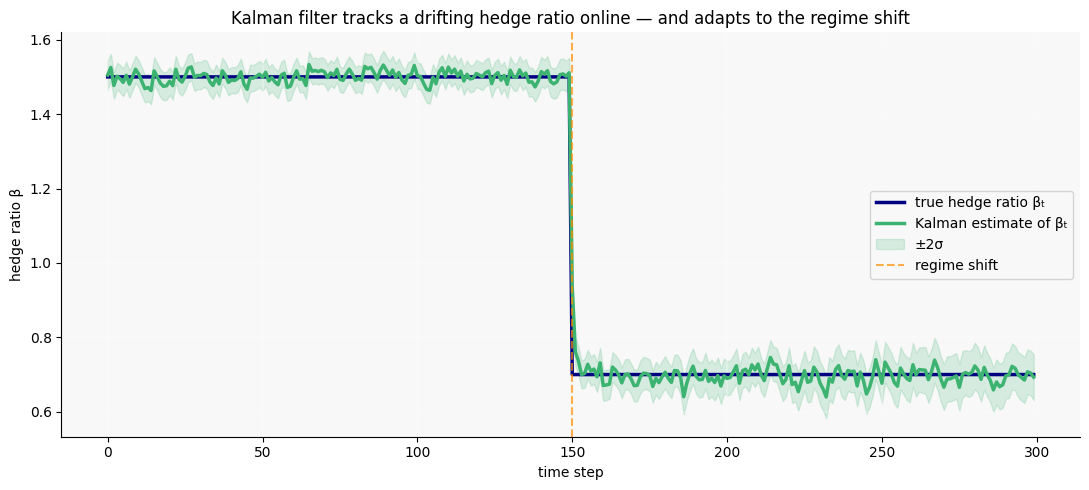

True beta after shift: 0.70   |   Kalman estimate at end: 0.69


In [11]:
# --- Synthetic pair where the TRUE hedge ratio shifts from 1.5 -> 0.7 ---
N = 300
x_asset = np.cumsum(np.random.normal(0, 1, N)) + 50          # price path of asset X
true_beta = np.where(np.arange(N) < 150, 1.5, 0.7)          # regime shift at t=150
y_asset = true_beta * x_asset + np.random.normal(0, 1.0, N)  # asset Y = beta*X + noise

# --- Kalman filter with beta as a 1D random-walk state ---
beta_est, beta_var = [], []
b   = 1.0          # initial beta guess
Pb  = 1.0          # initial uncertainty
Qb  = 1e-3         # how much beta is allowed to drift per step
Rb  = 1.0          # observation noise variance

for t in range(N):
    # predict: beta random-walks, so mean unchanged, variance grows
    Pb = Pb + Qb
    # update: observation is y_t = beta * x_t  ->  H = x_t
    Ht = x_asset[t]
    S  = Ht * Pb * Ht + Rb
    K  = Pb * Ht / S
    b  = b + K * (y_asset[t] - Ht * b)     # same innovation/gain/update pattern!
    Pb = (1 - K * Ht) * Pb
    beta_est.append(b); beta_var.append(Pb)

beta_est = np.array(beta_est); beta_var = np.array(beta_var)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(true_beta, color=C["truth"], lw=2.5, label="true hedge ratio βₜ")
ax.plot(beta_est, color=C["fused"], lw=2.5, label="Kalman estimate of βₜ")
ax.fill_between(range(N), beta_est-2*np.sqrt(beta_var), beta_est+2*np.sqrt(beta_var),
                color=C["fused"], alpha=0.18, label="±2σ")
ax.axvline(150, color=C["accent"], ls="--", alpha=0.7, label="regime shift")
ax.set_xlabel("time step"); ax.set_ylabel("hedge ratio β")
ax.set_title("Kalman filter tracks a drifting hedge ratio online — and adapts to the regime shift")
ax.legend(loc="center right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"True beta after shift: 0.70   |   Kalman estimate at end: {beta_est[-1]:.2f}")

The filter locks onto $\beta = 1.5$, then **smoothly relearns** $\beta = 0.7$ after the regime shift — no fixed window, no look-ahead, updating one tick at a time. Crank $Q_\beta$ up to adapt faster (but noisier); turn it down to be smoother (but slower to react). The *same* $Q/R$ trade-off, doing real work.

---

## 8 · Summary

The whole filter is one idea — *fuse a prediction with a measurement, weighting by certainty* — applied recursively.

| Concept | Key Idea |
|---------|----------|
| **Core idea** | Optimally combine a noisy prediction with a noisy measurement by treating both as Gaussians and multiplying them |
| **Gaussian fusion** | $\mu = \mu_1 + K(\mu_2-\mu_1)$, $\sigma^2=(1-K)\sigma_1^2$ — the fused belief is always *narrower* than either input |
| **State-space model** | $\mathbf{x}_t = F\mathbf{x}_{t-1}+\mathbf{w}$, $\;\mathbf{z}_t = H\mathbf{x}_t+\mathbf{v}$ — hidden state + noisy partial observation |
| **Predict step** | Push mean through physics ($F\hat{\mathbf{x}}$); grow uncertainty ($FPF^\top + Q$) |
| **Update step** | Innovation $\mathbf{y}=\mathbf{z}-H\hat{\mathbf{x}}^-$, gain $K=P^-H^\top S^{-1}$, correct $\hat{\mathbf{x}}^- + K\mathbf{y}$, shrink $P$ |
| **Kalman gain $K$** | The "trust dial" (0→1): high when our model is unsure or the sensor is precise; low otherwise |
| **Innovation** | $\mathbf{z}-H\hat{\mathbf{x}}^-$ — the surprise; the only thing that moves the estimate |
| **Process noise $Q$** | How much we distrust our own model — bigger ⇒ twitchier, more responsive |
| **Measurement noise $R$** | How much we distrust the sensor — bigger ⇒ smoother, laggier |
| **$Q/R$ ratio** | The single knob for smoothness vs. responsiveness — same as bias-variance |
| **Steady state** | Gain & covariance converge to constants (Riccati solution) — filter becomes a fixed linear filter |
| **Quant use** | Online estimation of hidden, drifting signals: time-varying hedge ratio β, fair value under microstructure noise, dynamic mean |

> **📌 Interview-ready one-liner:** *"A Kalman filter recursively maintains a Gaussian belief over a hidden state. Each step it predicts forward through a linear model (inflating uncertainty), then corrects with the measurement using a gain that optimally weights model vs. data by their relative variances."*

**Things to remember for interviews:**
- It's *optimal* (minimum mean-squared error) **only** under linear dynamics + Gaussian noise. Nonlinear? → Extended (EKF) or Unscented (UKF) Kalman filter.
- It's **recursive / online** — O(1) memory, no refitting, no look-ahead bias. Perfect for streaming market data.
- The gain converges; the *innovation* should look like white noise if your model is right (a useful diagnostic).